# ** Bayes ingenuo**

El objetivo de este libro de notas es presentar la técnica de Naive Bayes como alternativa al problema de clasificación.

In [1]:
if (!require('readxl')) install.packages('readxl')
if (!require('caret')) install.packages('caret')
if (!require('MLmetrics')) install.packages('MLmetrics')
if (!require('e1071')) install.packages('e1071')

Loading required package: readxl

Loading required package: caret

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘caret’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘listenv’, ‘parallelly’, ‘future’, ‘globals’, ‘shape’, ‘future.apply’, ‘numDeriv’, ‘progressr’, ‘SQUAREM’, ‘diagram’, ‘lava’, ‘prodlim’, ‘proxy’, ‘iterators’, ‘clock’, ‘gower’, ‘hardhat’, ‘ipred’, ‘timeDate’, ‘e1071’, ‘foreach’, ‘ModelMetrics’, ‘plyr’, ‘pROC’, ‘recipes’, ‘reshape2’


Loading required package: MLmetrics

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘MLmetrics’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘bitops’, ‘gtools’, ‘caTools’, ‘gplots’, ‘ROCR’


Loading required package: e1071



# ***  Naive Bayes (Bayes ingenuo) ***

Un modelo de clasificación que puede servir como pronóstico base o ingenuo, es conocido como Naive Bayes o Bayes ingenuo.

El resultado se basa en una relajación del Teorema de Bayes en la que la suposición principal es que las variables predictoras son independientes. Aunque es una suposición fuerte, en muchas ocasiones los resultados de Naive Bayes son bastante competitivos, y serán mucho mejores en la medida en que la suposición se cumpla.

# Data and business understanding

Los datos corresponden a una encuesta a 880 personas con respecto a su preferencia entre 3 opciones al desayuno: Avena, Barrita de desayuno o cereal. El objetivo es poder predecir una preferencia de acuerdo a información demográfica disponible que permitiera realizar promociones específicas.

In [2]:
library(readxl)
library(caret)
library(MLmetrics)
library(ROCR)
library(e1071)

Loading required package: ggplot2

Loading required package: lattice


Attaching package: ‘MLmetrics’


The following objects are masked from ‘package:caret’:

    MAE, RMSE


The following object is masked from ‘package:base’:

    Recall




In [3]:
cereal<-read.csv("cereal2.csv", header=TRUE, sep=";", dec=",")
str(cereal)

'data.frame':	880 obs. of  5 variables:
 $ edadcat : chr  "Menor de 31" "46-60" "Más de 60" "31-45" ...
 $ genero  : chr  "Hombre" "Hombre" "Hombre" "Mujer" ...
 $ ecivil  : chr  "Casado" "Casado" "Casado" "Casado" ...
 $ activo  : chr  "En activo" "Sin actividad" "Sin actividad" "En activo" ...
 $ desayuno: chr  "Cereales" "Barrita de desayuno" "Avena" "Avena" ...


Los predictores son:

Edadcat: La edad en categorías de edad.

Genero: El género del encuestado

ecivil: el estado civil

activo: Si la persona es o no activo en su vida diaria (sedentario o no)

Vamos a hacer un pequeño arreglo con el nombre de la edad categorizada y separar en bases de entrenamiento y validación en una partición 50%-50%

In [4]:
#un pequeño arreglo
colnames(cereal)[1]<-"edadcat"

In [5]:
#genero entrenamiento y validacion para cereal
set.seed(19854)
sample <- sample.int(nrow(cereal), floor(.7*nrow(cereal)))
cereal.train <- cereal[sample, ]
cereal.test <- cereal[-sample, ]

# Modelling

La creación del modelo de Naive Bayes es relativamente simple, pues no existen hiperparámetros por sintonizar o parámetros a entrenar. Se trata simplemente de calcular las probabilidades de la categoría a predecir a partir de las categorías de las predictoras, suponiendo independencia entre ellas usando el Teorema de Bayes.

In [6]:
naivetest<-naiveBayes(cereal.train$desayuno~.,cereal.train)

Un resultado a observar son las probabilidades a priori, que corresponden simplemente a las tasas base de las categorías a predecir. El segundo resultado a observar son las probabilidades marginales del predictor dada la categoría a predecir.

In [7]:
#tasas base
naivetest$apriori

Y
              Avena Barrita de desayuno            Cereales 
                219                 168                 229 

In [8]:
#probabilidades marginales
naivetest$tables$genero

                     genero
Y                        Hombre     Mujer
  Avena               0.5022831 0.4977169
  Barrita de desayuno 0.4226190 0.5773810
  Cereales            0.4716157 0.5283843

In [9]:
naivetest$tables$edadcat


                     edadcat
Y                          31-45      46-60  Más de 60 Menor de 31
  Avena               0.06392694 0.29680365 0.63470320  0.00456621
  Barrita de desayuno 0.41071429 0.16666667 0.07142857  0.35119048
  Cereales            0.27510917 0.26637555 0.18777293  0.27074236

In [10]:
naivetest$tables$ecivil


                     ecivil
Y                        Casado   Soltero
  Avena               0.6666667 0.3333333
  Barrita de desayuno 0.5416667 0.4583333
  Cereales            0.6986900 0.3013100

In [11]:
naivetest$tables$activo

                     activo
Y                     En activo Sin actividad
  Avena               0.3150685     0.6849315
  Barrita de desayuno 0.6488095     0.3511905
  Cereales            0.4366812     0.5633188

La primera tabla nos permite ver una base de datos bastante balanceada. Las siguientes tablas permiten ver qué característica individual parece discriminar mejor el desayuno elegido.


Por ejemplo, dado que se consume barrita de desayuno hay una mayor probabilidad de que sea mujer, o dado que se consume avena hay una buena probabilidad de que se trate de una persona de más de 42 años, particularmente los mayores de 60.

## Evaluation

Creamos el objeto de predicción que nos permite ver el desempeño en la base de datos de validación

In [12]:
#guarda las probabilidades (para curva COR)
prednaiveprob<-predict(naivetest, cereal.test, type="raw")

In [13]:
#guarda el pronóstico
prednaive<-predict(naivetest, cereal.test)

In [15]:
str(prednaive)

 Factor w/ 3 levels "Avena","Barrita de desayuno",..: 1 3 2 3 2 1 1 1 3 1 ...


In [18]:
#generar la matriz de confusión
naiveconf<-confusionMatrix(prednaive,as.factor(cereal.test$desayuno))
naiveconf$table

                     Reference
Prediction            Avena Barrita de desayuno Cereales
  Avena                  67                   9       38
  Barrita de desayuno     7                  29       32
  Cereales               17                  25       40

In [19]:
as.data.frame(naiveconf$byClass)

,Sensitivity,Specificity,Pos Pred Value,Neg Pred Value,Precision,Recall,F1,Prevalence,Detection Rate,Detection Prevalence,Balanced Accuracy
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Class: Avena,0.7362637,0.7283237,0.5877193,0.8400000,0.5877193,0.7362637,0.6536585,0.3446970,0.2537879,0.4318182,0.7322937
Class: Barrita de desayuno,0.4603175,0.8059701,0.4264706,0.8265306,0.4264706,0.4603175,0.4427481,0.2386364,0.1098485,0.2575758,0.6331438
Class: Cereales,0.3636364,0.7272727,0.4878049,0.6153846,0.4878049,0.3636364,0.4166667,0.4166667,0.1515152,0.3106061,0.5454545


Nótese que la predicción requiere de 3 clases diferentes. Es por ello que la matriz de confusión presenta los indicadores divididos por cada uno de los tres valores, para saber qué tan buena es la predicción para cada posible desayuno. Si se hubiese definido el desayuno a predecir, los resultados hubiesen salido solo para ese tipo de desayuno.

Como puede analizarse, la avena es la más fácil de predecir (F=65%, precisión 59% y exhaustividad 74%). Para las otras dos clases, los F scores son menores al 50%.

Cuando se tiene un problema multiclase, se suelen obtener tendencias centrales del F score para todas las clases, conocidas como F micro y F macro. La F macro es una media ponderada de los F score de cada categoría; la F micro es el mismo *accuracy*, es decir, el total de éxitos sobre el total de la base.  



In [22]:
##calcular macro y micro F1
guarda<-naiveconf$table
guarda2<-as.data.frame(naiveconf$byClass)
guarda2$n<-naivetest$apriori
##Macro F1
macrof1<-mean(guarda2$F1)
##Weighted F1
macrof1_weighted<-weighted.mean(guarda2$F1,guarda2$n)
##micro f1= accuracy
microf1<-(guarda[1,1]+guarda[2,2]+guarda[3,3])/(sum(guarda))
macrof1
macrof1_weighted
microf1

[1] 0.5043578

[1] 0.508035

[1] 0.5151515


Los siguientes son los pasos para obtener una curva COR para la avena.

In [23]:
#crear resultados 1 o 0 para la predicción de Avena
avenas<-ifelse(cereal.test$desayuno=="Avena",1,0)

In [24]:
#crear el objeto de prediccion
predcor<-prediction(prednaiveprob[,1], avenas)

In [25]:
curvaROC<-performance(predcor,measure="tpr",x.measure="fpr")

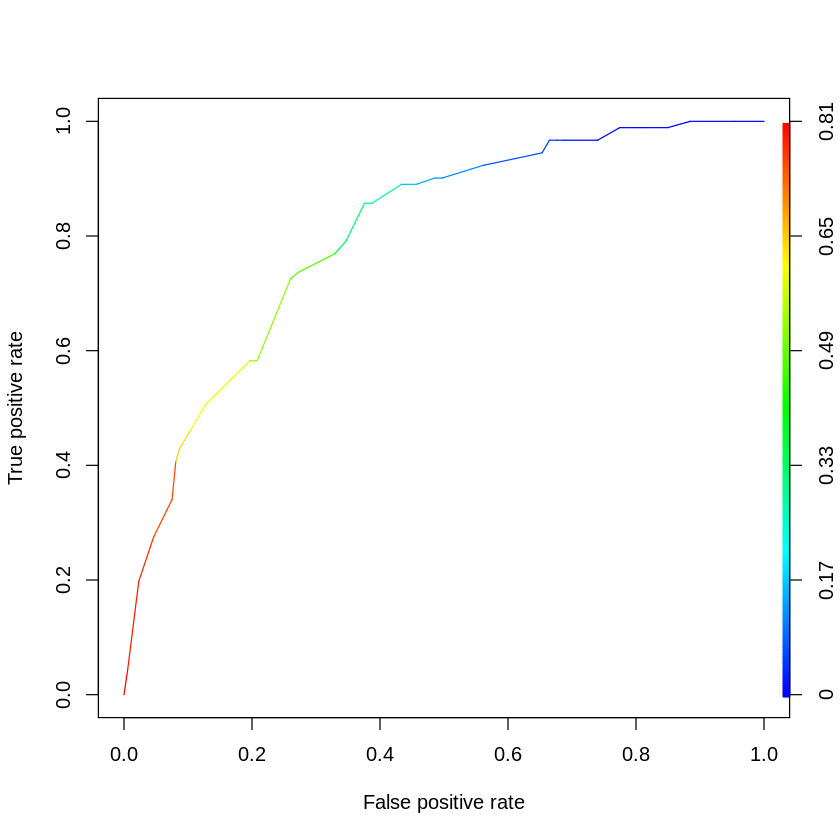

In [43]:
#grafico de la curva
plot(curvaROC, colorize=TRUE,colorkey=TRUE)

In [27]:
#calcular el AUC
auc<-performance(predcor,measure = "auc")
auc <- auc@y.values[[1]]
#ver el AUC
auc

[1] 0.8014673

El resultado para avena es bueno. Sin embargo miremos el resultado para cereal.

In [28]:
#crear resultados 1 o 0 para la predicción de cereal
cerealk<-ifelse(cereal.test$desayuno=="Cereales",1,0)

In [29]:
#crear el objeto de prediccion
predcor2<-prediction(prednaiveprob[,3], cerealk)

In [30]:
curvaROC2<-performance(predcor2,measure="tpr",x.measure="fpr")

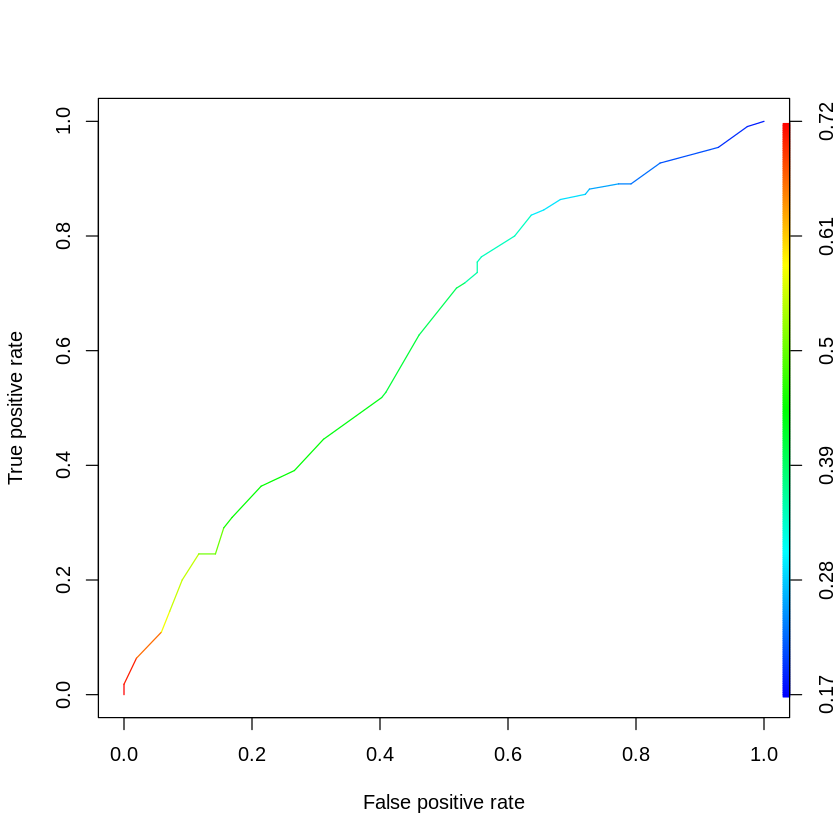

In [44]:
#grafico de la curva
plot(curvaROC2,colorize=TRUE,colorkey=TRUE)

In [32]:
#calcular el AUC
auc2<-performance(predcor2,measure = "auc")
auc2<- auc2@y.values[[1]]

In [33]:
#ver el AUC
auc2

[1] 0.6217532

El resultado para cereal es de tan solo 62.2%, por lo que Naive Bayes no es muy satisfactorio para predecir esta categoría.

Aquí también podemos generar todos los puntos de corte, y calcular ganancias.

In [34]:
#guardar las exhaustividades y puntos de corte
tablafinan<-performance(predcor2,measure="rec")
cutoffs<-unlist(tablafinan@x.values)
recalls<-unlist(tablafinan@y.values)

In [35]:
#guardar las precisiones
tablafina2<-performance(predcor2,measure="prec")
precisions<-unlist(tablafina2@y.values)

In [36]:
#guardar f scores
tablafina3<-performance(predcor2,measure="f")
fscores<-unlist(tablafina3@y.values)

In [37]:
#crear la tabla conjunta
tablacruce<-as.data.frame(cbind(cutoffs,precisions,recalls,fscores))

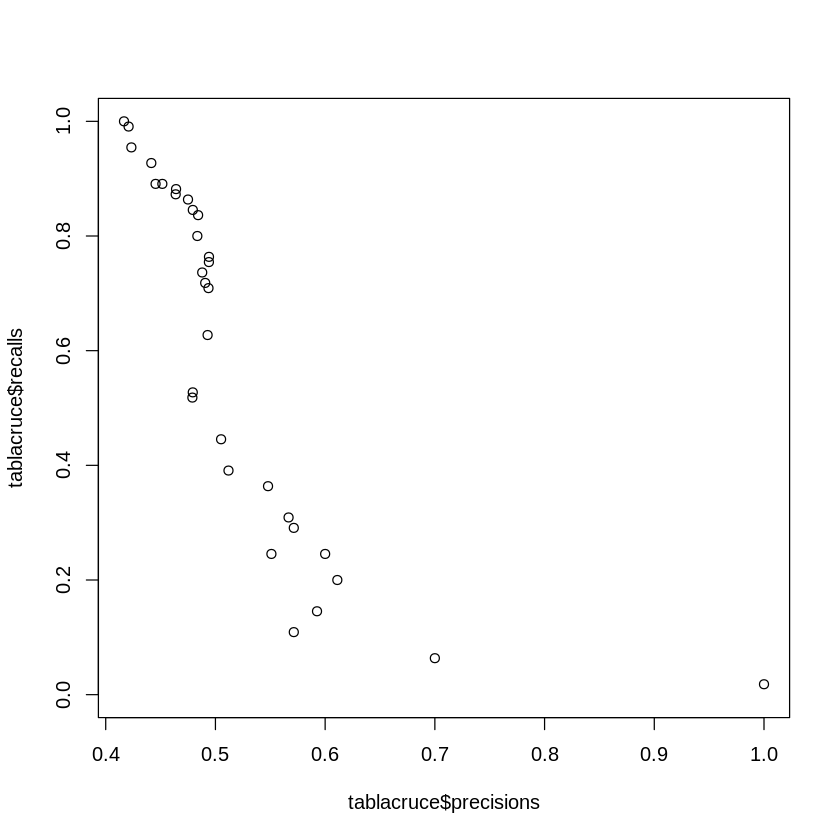

In [38]:
#ver precisiones versus exhaustividad
plot(tablacruce$precisions,tablacruce$recalls)

Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”


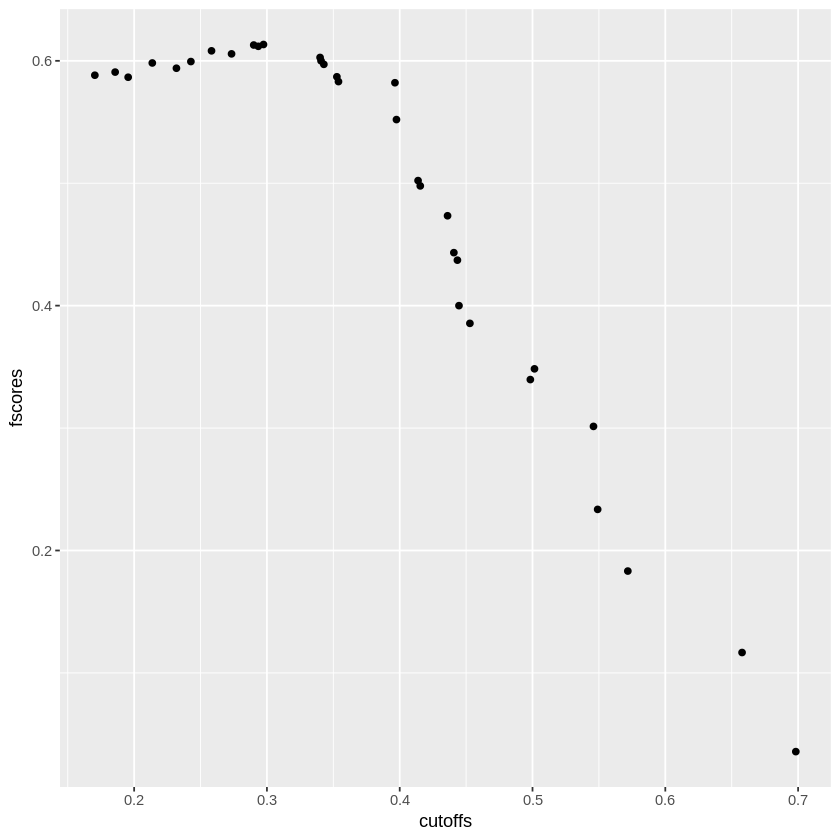

In [39]:
#ver el cutoff que maximiza f score
ggplot(tablacruce, aes(cutoffs,fscores))+geom_point()

In [40]:
#calcular las ganancias
tabla<-table(cereal.test$desayuno)
prop.table(tabla)[3]
tablacruce$wins<-prop.table(tabla)[3]*recalls*(250-(100/precisions))

Cereales 
0.4166667

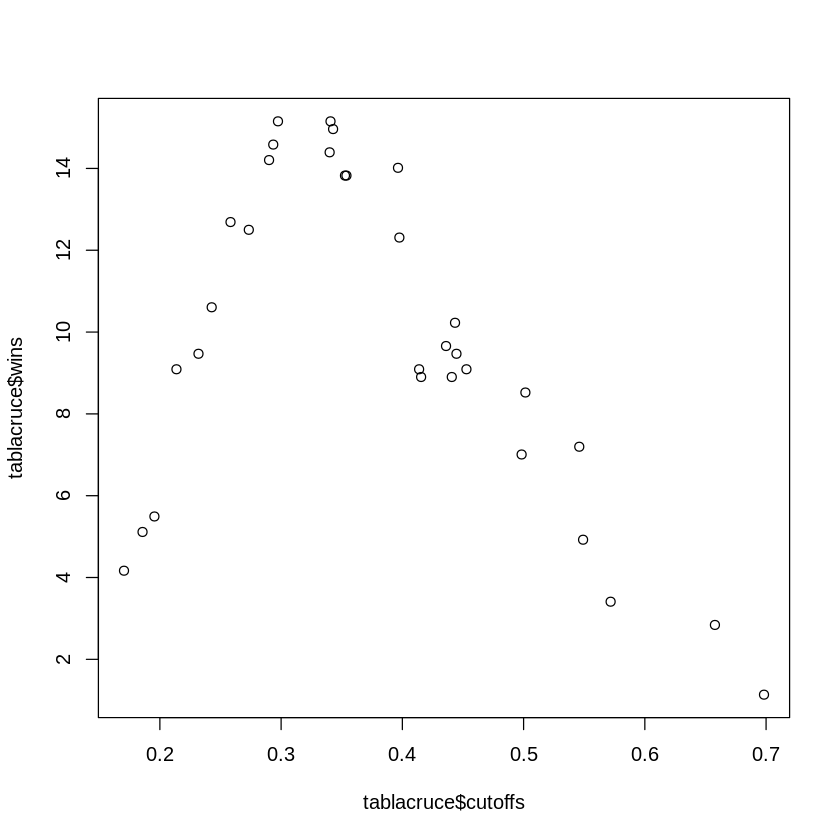

In [41]:
#pintar las ganancias versus los cutoffs
plot(tablacruce$cutoffs,tablacruce$wins)

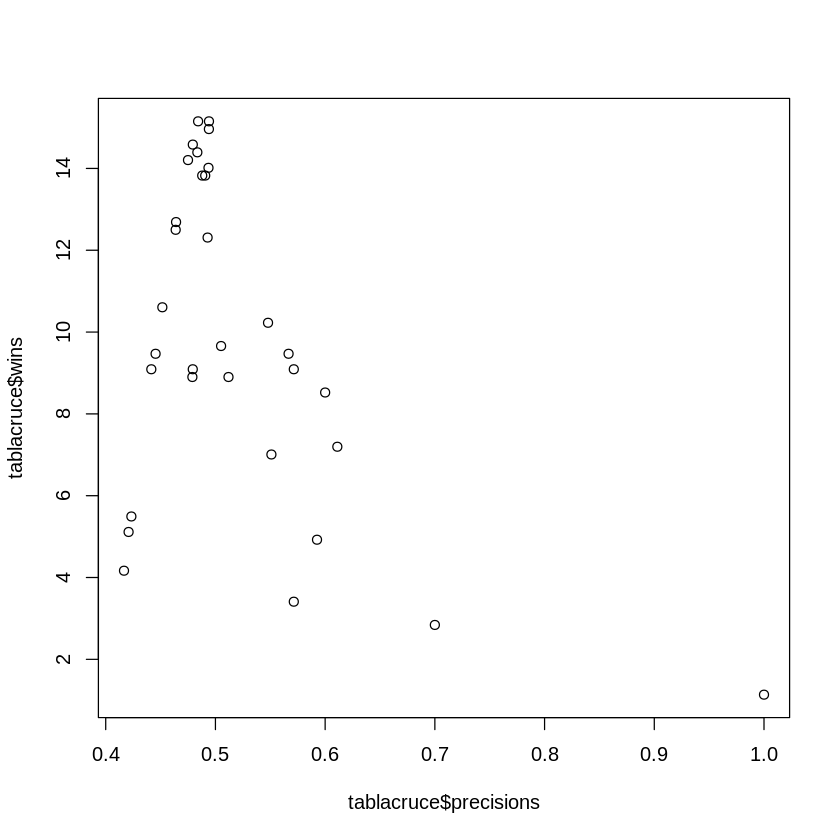

In [42]:
#ver las ganancias frente a la precisi?n
plot(tablacruce$precisions,tablacruce$wins)

## Conclusión

En este libro de notas revisamos la técnica de bayes ingenuo para de clasificación, que puede usarse como línea de base ingenua y que es sorprendentemente buena a pesar de su sencillez. Un modelo más sofisticado debe demostrar su utilidad frente a modelos ingenuos para justificar el esfuerzo de su realización. Así mismos esta técnica básica suelen ser altamente escalables a grandes volúmenes de datos.

